In [1]:
#class imbalance >> whan one class has higher percentage
#handale class imbalance priblem

#up-sampling
#down-sampling
#smote

In [2]:
import numpy as np
import pandas as pd

np.random.seed(1) #for reproducibility

no_sample = 1000
class_0_ratio = 0.9
no_class_0 = int(no_sample * class_0_ratio)
no_class_1 = 100

In [4]:
no_class_0,no_class_1

(900, 100)

In [10]:
class_0 = {'feature1': np.random.normal(0, 1, no_class_0),
           'feature2': np.random.normal(0, 1, no_class_0),
           'target': [0]*no_class_0}

In [13]:
class_0 = pd.DataFrame(class_0)

In [14]:
class_0

,feature1,feature2,target
0,-0.453503,-0.098819,0
1,-0.820905,-0.270149,0
2,0.940219,1.745068,0
3,-1.411293,-0.180558,0
4,0.884148,-0.202378,0
...,...,...,...
895,-1.140488,0.747622,0
896,0.501016,0.943634,0
897,0.225767,-0.425562,0
898,-1.089087,0.805778,0


In [15]:
class_1 = pd.DataFrame({'feature1': np.random.normal(3, 1, no_class_1),
           'feature2': np.random.normal(3, 1, no_class_1),
           'target': [1]*no_class_1})

In [16]:
class_1

,feature1,feature2,target
0,2.448642,3.993568,1
1,2.395812,2.957136,1
2,4.234969,3.642214,1
3,2.896889,4.847031,1
4,2.631146,2.629001,1
...,...,...,...
95,3.695896,3.194242,1
96,4.576039,1.676169,1
97,2.558864,2.633902,1
98,1.494603,1.938870,1


In [19]:
df = pd.concat([class_0, class_1]).reset_index(drop = True)

In [20]:
df

,feature1,feature2,target
0,-0.453503,-0.098819,0
1,-0.820905,-0.270149,0
2,0.940219,1.745068,0
3,-1.411293,-0.180558,0
4,0.884148,-0.202378,0
...,...,...,...
995,3.695896,3.194242,1
996,4.576039,1.676169,1
997,2.558864,2.633902,1
998,1.494603,1.938870,1


In [21]:
df.target.value_counts()

target
0    900
1    100
Name: count, dtype: int64

upsampling

In [22]:
#upsampling

df_minority = df[df.target == 1]
df_majority = df[df.target == 0]

In [27]:
from sklearn.utils import resample

In [29]:
#replace = true with replacement
df_minority_upsampled = resample(df_minority, replace= True, n_samples= len(df_majority),random_state = 1)

In [31]:
df_minority_upsampled.shape

(900, 3)

In [36]:
df_minority_upsampled.tail()

,feature1,feature2,target
936,2.914703,3.532064,1
998,1.494603,1.938870,1
901,2.395812,2.957136,1
932,5.048985,2.639944,1
930,4.183919,3.166417,1


In [39]:
df_upsampled = pd.concat([df_majority, df_minority_upsampled])

In [40]:
df_upsampled

,feature1,feature2,target
0,-0.453503,-0.098819,0
1,-0.820905,-0.270149,0
2,0.940219,1.745068,0
3,-1.411293,-0.180558,0
4,0.884148,-0.202378,0
...,...,...,...
936,2.914703,3.532064,1
998,1.494603,1.938870,1
901,2.395812,2.957136,1
932,5.048985,2.639944,1


In [42]:
df_upsampled.target.value_counts()

target
0    900
1    900
Name: count, dtype: int64

downsampling

In [43]:
df_minority

,feature1,feature2,target
900,2.448642,3.993568,1
901,2.395812,2.957136,1
902,4.234969,3.642214,1
903,2.896889,4.847031,1
904,2.631146,2.629001,1
...,...,...,...
995,3.695896,3.194242,1
996,4.576039,1.676169,1
997,2.558864,2.633902,1
998,1.494603,1.938870,1


In [44]:
df_majority

,feature1,feature2,target
0,-0.453503,-0.098819,0
1,-0.820905,-0.270149,0
2,0.940219,1.745068,0
3,-1.411293,-0.180558,0
4,0.884148,-0.202378,0
...,...,...,...
895,-1.140488,0.747622,0
896,0.501016,0.943634,0
897,0.225767,-0.425562,0
898,-1.089087,0.805778,0


In [48]:
#downsampling

df_majority_downsampled = resample(df_majority, replace= False, n_samples= len(df_minority), random_state=1)

In [49]:
df_majority_downsampled

,feature1,feature2,target
860,0.122837,0.780678,0
880,-1.586623,0.215341,0
874,-1.448482,-0.603646,0
780,0.502019,0.363966,0
525,0.452069,0.992134,0
...,...,...,...
494,0.781319,-0.492905,0
255,0.297858,-0.696128,0
672,-0.053589,-1.198305,0
481,-0.644226,-0.102980,0


In [51]:
df_downsampled = pd.concat([df_minority, df_majority_downsampled])

In [52]:
df_downsampled

,feature1,feature2,target
900,2.448642,3.993568,1
901,2.395812,2.957136,1
902,4.234969,3.642214,1
903,2.896889,4.847031,1
904,2.631146,2.629001,1
...,...,...,...
494,0.781319,-0.492905,0
255,0.297858,-0.696128,0
672,-0.053589,-1.198305,0
481,-0.644226,-0.102980,0


In [53]:
df

,feature1,feature2,target
0,-0.453503,-0.098819,0
1,-0.820905,-0.270149,0
2,0.940219,1.745068,0
3,-1.411293,-0.180558,0
4,0.884148,-0.202378,0
...,...,...,...
995,3.695896,3.194242,1
996,4.576039,1.676169,1
997,2.558864,2.633902,1
998,1.494603,1.938870,1


In [54]:
df_downsampled.target.value_counts()

target
1    100
0    100
Name: count, dtype: int64

SMOTE

In [55]:
#smote >> synthetic minority oversampling technique

In [57]:
from sklearn.datasets import make_classification

In [58]:
x,y = make_classification(n_samples = 1000, n_redundant=0, n_features= 2, n_clusters_per_class=1, weights=[0.90], random_state=1)

In [59]:
x

array([[ 1.53682958, -1.39869399],
       [ 1.55110839,  1.81032905],
       [ 1.29361936,  1.01094607],
       ...,
       [-0.55662536, -0.15983725],
       [ 1.00499902,  0.93628981],
       [ 1.46210987,  1.14497791]])

In [60]:
y

array([1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [63]:
len(y[y==0])

894

In [66]:
df1 = pd.DataFrame(x, columns=['f1', 'f2'])
df2 = pd.DataFrame(y, columns=['target'])
final_df = pd.concat([df1, df2], axis= 1)
final_df

,f1,f2,target
0,1.536830,-1.398694,1
1,1.551108,1.810329,0
2,1.293619,1.010946,0
3,1.119889,1.632518,0
4,1.042356,1.121529,0
...,...,...,...
995,2.210439,2.006772,0
996,1.910941,2.011860,0
997,-0.556625,-0.159837,0
998,1.004999,0.936290,0


In [67]:
final_df.target.value_counts()

target
0    894
1    106
Name: count, dtype: int64

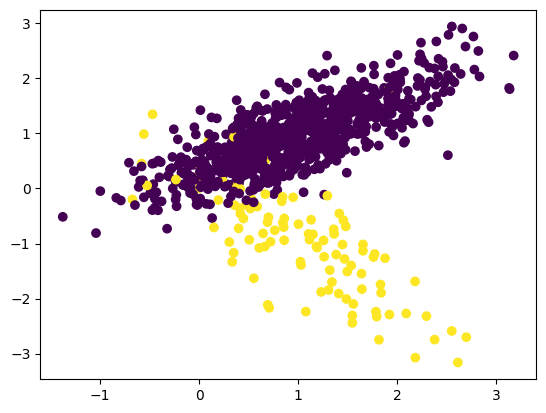

In [68]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'], final_df['f2'], c=final_df['target'])

In [69]:
#smote 
#install imblearn

In [71]:
from imblearn.over_sampling import SMOTE

In [72]:
oversample = SMOTE()

In [73]:
x, y = oversample.fit_resample(final_df[['f1', 'f2']], final_df['target'])

In [74]:
x.shape

(1788, 2)

In [75]:
y.shape

(1788,)

In [76]:
len(y[y == 0])

894

In [77]:
df1 = pd.DataFrame(x, columns=['f1', 'f2'])
df2 = pd.DataFrame(y, columns=['target'])
oversample_df = pd.concat([df1, df2], axis= 1)
oversample_df

,f1,f2,target
0,1.536830,-1.398694,1
1,1.551108,1.810329,0
2,1.293619,1.010946,0
3,1.119889,1.632518,0
4,1.042356,1.121529,0
...,...,...,...
1783,0.395727,0.068901,1
1784,0.105746,-0.115038,1
1785,1.332788,-0.796049,1
1786,1.290884,-0.771616,1


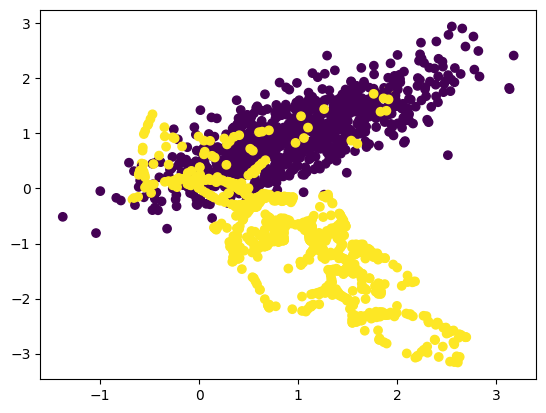

In [78]:
plt.scatter(oversample_df['f1'], oversample_df['f2'], c=oversample_df['target'])

In [79]:
oversample_df[oversample_df.target ==1]

,f1,f2,target
0,1.536830,-1.398694,1
8,2.552644,-2.588927,1
14,1.115618,-0.929017,1
17,1.558391,-2.098504,1
20,-0.672512,-0.198716,1
...,...,...,...
1783,0.395727,0.068901,1
1784,0.105746,-0.115038,1
1785,1.332788,-0.796049,1
1786,1.290884,-0.771616,1


In [80]:
df_minority

,feature1,feature2,target
900,2.448642,3.993568,1
901,2.395812,2.957136,1
902,4.234969,3.642214,1
903,2.896889,4.847031,1
904,2.631146,2.629001,1
...,...,...,...
995,3.695896,3.194242,1
996,4.576039,1.676169,1
997,2.558864,2.633902,1
998,1.494603,1.938870,1
